# Ray Calculation

Current step as of Fri Aug 7: Seems to be a units issue or some scale problem for the IAT. Gets bigger instead of smaller

In [1]:
import numpy as np
from astropy import units as u

In [2]:
pwd

'/Users/ibehbehani/csm_pipeline'

In [3]:
import csv

csm_2d_density_list = []
with open("csm_2d_density.csv") as csvfile:
    reader = csv.reader(csvfile, quoting=csv.QUOTE_NONNUMERIC) # change contents to floats
    for row in reader: # each row is a list
        csm_2d_density_list.append(row)

In [4]:
csm_2d_density = np.array(csm_2d_density_list)


In [5]:
csm_2d_density[np.isnan(csm_2d_density)] = 0



In [6]:
csm_2d_density.shape

(1000, 1000)

In [7]:
np.max(csm_2d_density)

np.float64(0.00024578104746353477)

In [8]:
center_x = 499
center_y = 499
pix_size_arcsec = 0.005*u.arcsec

In [9]:
from matplotlib import pyplot as plt

Text(0, 0.5, '$\\Delta$ Dec (arc)')

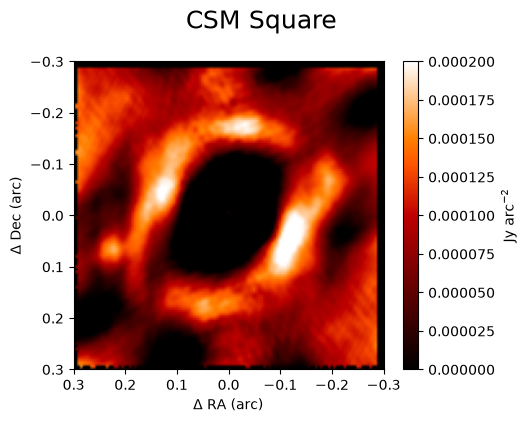

In [38]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis1,yaxis1,csm_2d_density, cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [11]:
from radial_interpolation import *

hello again


In [12]:
pix_size_arcsec

<Quantity 0.005 arcsec>

499 499 0.005 arcsec True


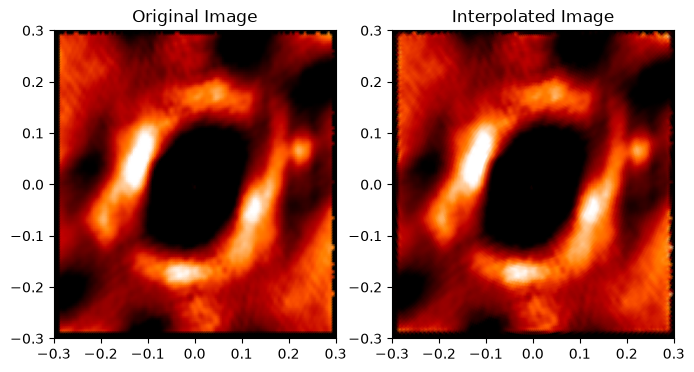

In [13]:
x_grid,y_grid,interp_csm = radial_interp(csm_2d_density, center_x,center_y,
              n_lines = 401, n_pts = 400, pix_arc = pix_size_arcsec,plot_bool=True,vmax=0.0002)

In [14]:
np.max(x_grid)

np.float64(999.0)

In [15]:
interp_csm.shape

(401, 400)

Text(0.5, 1.0, 'Interpolated Image')

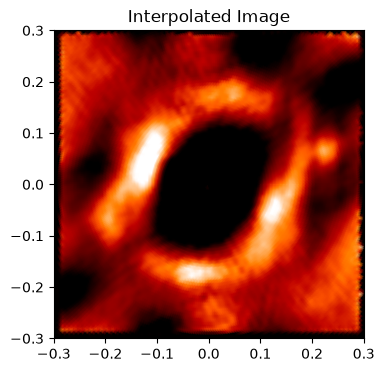

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
xaxis = x_grid*pix_size_arcsec.value-(center_x*pix_size_arcsec.value)
yaxis = y_grid*pix_size_arcsec.value-(center_y*pix_size_arcsec.value)
ax.pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

rnge = 0.3
ax.set_xlim(-rnge,rnge)
ax.set_ylim(-rnge,rnge)


ax.set_title("Interpolated Image")

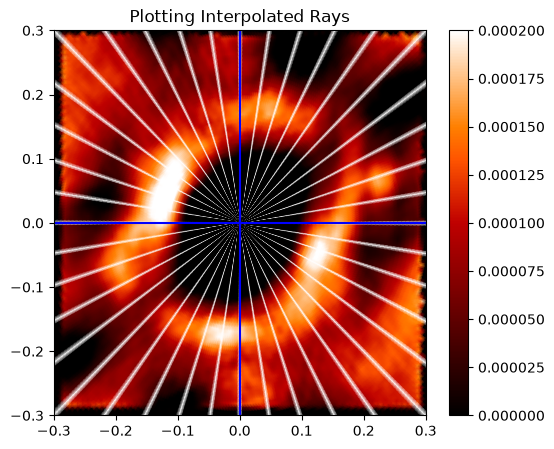

In [17]:
plot_rays(x_grid,y_grid,interp_csm,vmax=0.0002)


# Inverse Abel Transform

In [18]:
from abel import do_abel

In [19]:
interp_csm.shape

(401, 400)

In [20]:
interp_csm[0,:].shape
interp_csm[:,0].shape

(401,)

In [21]:
from radial import sm

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
x_pc = sm(168,xaxis)*u.pc
y_pc = sm(168,yaxis)*u.pc

In [23]:
x_pc.shape

(401, 400)

In [24]:
radius_2d_pc = np.array([[0.0]*x_pc.shape[1]]*x_pc.shape[0])
#fill pc array of radii
for i in range(x_pc.shape[0]):
        for j in range(x_pc.shape[1]):
            c = (x_pc[i,j].value)**2+(y_pc[i,j].value)**2
            radius_2d_pc[i,j] = np.sqrt(c)

In [32]:
xaxis.shape

(1000,)

In [39]:
radius_2d_arc = np.array([[0.0]*xaxis.shape[1]]*xaxis.shape[0])
#fill pc array of radii
for i in range(xaxis.shape[0]):
        for j in range(xaxis.shape[1]):
            c = (xaxis[i,j])**2+(yaxis[i,j])**2
            radius_2d_arc[i,j] = np.sqrt(c)

In [40]:
interp_csm.shape

(401, 400)

In [41]:
radius_2d_arc.shape

(401, 400)

In [42]:
interp_csm

array([[ 5.91682083e-022,  0.00000000e+000,  0.00000000e+000, ...,
         0.00000000e+000,  3.08334362e-257,  0.00000000e+000],
       [ 5.91682083e-022, -5.87537584e-005, -1.87405544e-004, ...,
        -1.99090903e-256,  4.75874060e-257, -1.88518691e-257],
       [ 5.91682083e-022, -5.91910969e-005, -1.88616712e-004, ...,
         6.22506937e-256, -2.34076540e-256,  2.17189809e-256],
       ...,
       [ 5.91682083e-022, -5.73061128e-005, -1.83516352e-004, ...,
        -3.75425426e-256,  1.32947665e-256, -1.17444264e-256],
       [ 5.91682083e-022, -5.78109243e-005, -1.84852601e-004, ...,
        -3.30971454e-256,  7.92046197e-257, -3.14139846e-257],
       [ 5.91682083e-022, -5.82936193e-005, -1.86149682e-004, ...,
        -1.47411140e-256,  3.08334362e-257,  0.00000000e+000]],
      shape=(401, 400))

In [54]:
csm_abel = []
r_arr = np.zeros(len(interp_csm[i,:]))
row = np.zeros(len(interp_csm[i,:]))
m = 0

for i in range(len(interp_csm[:,0])):
    row = do_abel(interp_csm[i,:],radius_2d_arc[i,:],8.7055651*10-5)
#     F = interp_csm[i,:]
#     F[F<0]=0
#     s = radius_2d_arc[i,:]
#     dF_ds = np.gradient(F,s)

#     for j in range(len(s)-1):
#             r = (s[j]+s[j+1])/2
#             r_arr[j] = r
    
#             integ = np.trapezoid(dF_ds[j+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])
    
#             row[j]= (-1/np.pi)* integ


    csm_abel.append(row)


In [55]:
row_0 = do_abel(interp_csm[0,:],radius_2d_arc[0,:],0)

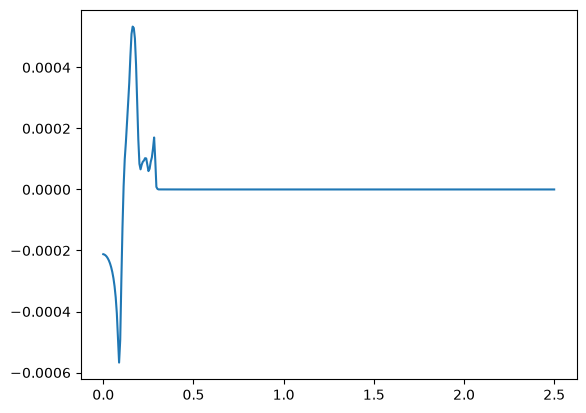

In [56]:
plt.plot(xaxis[0,:],row_0)

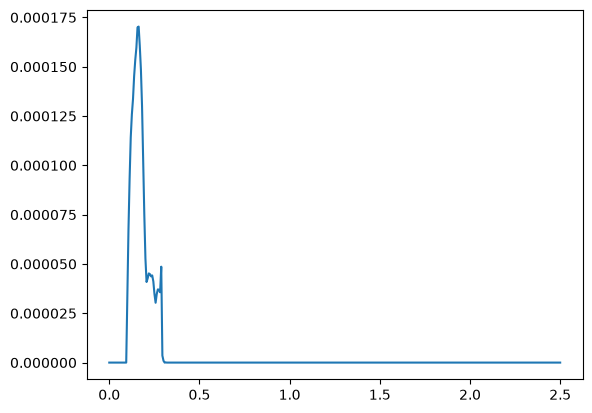

In [57]:
plt.plot(xaxis[0,:],interp_csm[0,:])

In [58]:
csm_abel = np.array(csm_abel)

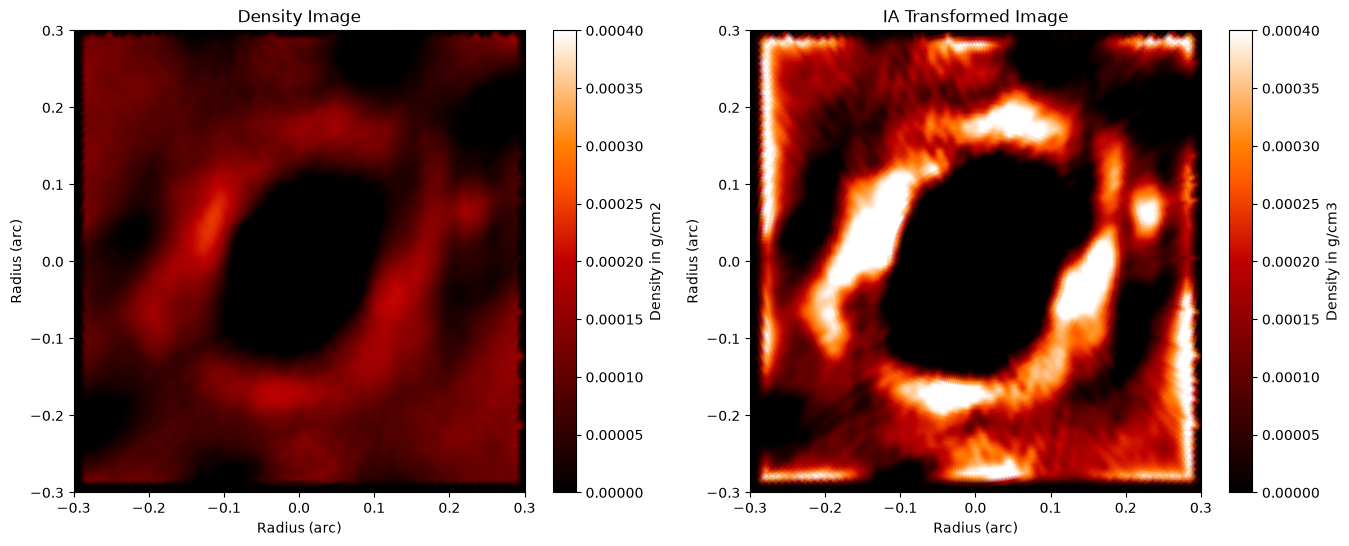

In [59]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))

im0 = ax[0].pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0004)

rnge = 0.3
ax[0].set_xlim(-rnge,rnge)
ax[0].set_ylim(-rnge,rnge)
ax[0].set_xlabel("Radius (arc)")
ax[0].set_ylabel("Radius (arc)")

ax[0].set_title("Density Image")
fig.colorbar(im0,label = "Density in g/cm2")

### abel image

im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0004)

ax[1].set_xlim(-rnge,rnge)
ax[1].set_ylim(-rnge,rnge)
ax[1].set_xlabel("Radius (arc)")
ax[1].set_ylabel("Radius (arc)")


ax[1].set_title("IA Transformed Image")
fig.colorbar(im1,label = "Density in g/cm3")

In [60]:
np.min(csm_abel)

np.float64(-0.0009543928251998955)

/var/folders/bd/zqhz_9jx7gn5z5xnr8ynvz5h0000gn/T/ipykernel_6053/664715605.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


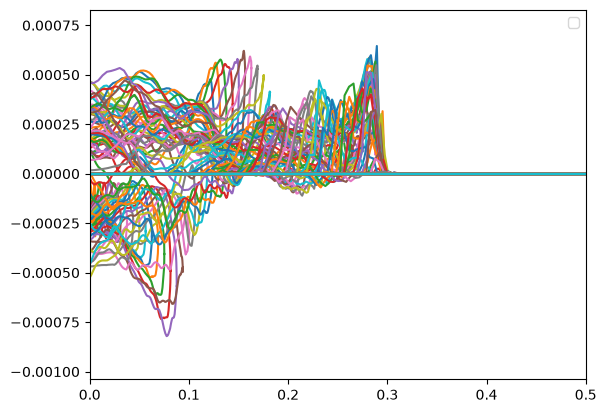

In [61]:
plt.plot(xaxis,csm_abel)
plt.xlim(0,0.5)
plt.legend()